### Step 1: Mount the Google Drive

Remember to use GPU runtime before mounting your Google Drive. (Runtime --> Change runtime type).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 2: Open the project directory

Replace `Your_Dir` with your own path.

In [ ]:
cd /content/drive/MyDrive/emg2qwerty

/content/drive/MyDrive/emg2qwerty


### Step 3: Install required packages

After installing them, Colab will require you to restart the session.

In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 553.6/553.6 kB 28.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of typer to determine which version is

### Step 4: Start your experiments!

- Remember to download and copy the dataset to this directory: `Your_Dir/emg2qwerty/data`.
- You may now start your experiments with any scripts! Below are examples of single-user training and testing (greedy decoding).
- **There are two ways to track the logs:**
  - 1. Keep `--multirun`, and the logs will not be printed here, but they will be saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/submitit_logs/`.
  - 2. Comment out `--multirun` and the logs will be printed in this notebook, but they will not be saved.

#### Training

- The checkpoints are saved in the folder `logs`, e.g., `logs/2025-02-09/18-24-15/checkpoints/`.

In [ ]:
%%bash
echo "Training started at: $(date)"

Training started at: Tue Mar  3 01:02:31 AM UTC 2026


In [ ]:
# Single-user training
!python -m emg2qwerty.train \
  user="single_user" \
  trainer.accelerator=gpu trainer.devices=1 \
  # --multirun

[2026-03-03 01:02:42,901][__main__][INFO] - 
Config:
user: single_user
dataset:
  train:
  - user: 89335547
    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f
  - user: 89335547
    session: 2021-06-02-1622679967-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f

In [ ]:
%%bash
echo "Training finished at: $(date)"

Training finished at: Tue Mar  3 01:21:19 AM UTC 2026


#### Testing:

- Replace `Your_Path_to_Checkpoint` with your checkpoint path.

In [ ]:
# # Single-user testing
# !python -m emg2qwerty.train \
#   user="single_user" \
#   checkpoint="Your_Path_to_Checkpoint" \
#   train=False trainer.accelerator=gpu \
#   decoder=ctc_greedy \
#   hydra.launcher.mem_gb=64 \
#   # --multirun

In [ ]:
import sys, os
sys.path.insert(0, os.getcwd())

In [ ]:
import os
import subprocess
import re

REPO_ROOT = os.getcwd()  # make sure this is the repo root

def run_rate(rate_hz: int, max_epochs: int = 30):
    env = os.environ.copy()
    env["PYTHONPATH"] = REPO_ROOT

    cmd = [
        "python", "emg2qwerty/train.py",
        'user="single_user"',
        "trainer.accelerator=gpu",
        "trainer.devices=1",
        "model=rnn",
        "transforms=log_spectrogram",
        f"resample.new_freq={rate_hz}",   # <- correct key
        f"trainer.max_epochs={max_epochs}",
    ]
    print("Running:", " ".join(cmd))
    proc = subprocess.run(cmd, capture_output=True, text=True, env=env)

    out = proc.stdout + "\n" + proc.stderr
    if proc.returncode != 0:
        print("Command failed. Output tail:\n")
        print(out[-3000:])
        raise RuntimeError(f"Training failed at {rate_hz} Hz")

    val_cer = re.findall(r"'val/CER':\s*([0-9.]+)", out)
    test_cer = re.findall(r"'test/CER':\s*([0-9.]+)", out)
    if not val_cer or not test_cer:
        print("Could not parse CER. Output tail:\n")
        print(out[-3000:])
        raise RuntimeError("Could not parse CER from output. Check logs.")

    return {
        "rate_hz": rate_hz,
        "val_cer": float(val_cer[-1]),
        "test_cer": float(test_cer[-1]),
        "raw_output": out,
    }

rates = [3000, 2500, 2000, 1500, 1000, 750, 500, 200]
results = [run_rate(r, max_epochs=30) for r in rates]
results


Running: python emg2qwerty/train.py user="single_user" trainer.accelerator=gpu trainer.devices=1 model=rnn transforms=log_spectrogram resample.new_freq=3000 trainer.max_epochs=30
Running: python emg2qwerty/train.py user="single_user" trainer.accelerator=gpu trainer.devices=1 model=rnn transforms=log_spectrogram resample.new_freq=2500 trainer.max_epochs=30
Running: python emg2qwerty/train.py user="single_user" trainer.accelerator=gpu trainer.devices=1 model=rnn transforms=log_spectrogram resample.new_freq=2000 trainer.max_epochs=30
Running: python emg2qwerty/train.py user="single_user" trainer.accelerator=gpu trainer.devices=1 model=rnn transforms=log_spectrogram resample.new_freq=1500 trainer.max_epochs=30
Running: python emg2qwerty/train.py user="single_user" trainer.accelerator=gpu trainer.devices=1 model=rnn transforms=log_spectrogram resample.new_freq=1000 trainer.max_epochs=30
Running: python emg2qwerty/train.py user="single_user" trainer.accelerator=gpu trainer.devices=1 model=rn

[{'rate_hz': 3000,
  'val_cer': 64.24457550048828,
  'test_cer': 62.87010955810547,
  'raw_output': '[2026-03-12 00:23:14,263][__main__][INFO] - \nConfig:\nuser: single_user\ndataset:\n  train:\n  - user: 89335547\n    session: 2021-06-03-1622765527-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f\n  - user: 89335547\n    session: 2021-06-02-1622681518-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f\n  - user: 89335547\n    session: 2021-06-04-1622863166-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f\n  - user: 89335547\n    session: 2021-07-22-1627003020-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f\n  - user: 89335547\n    session: 2021-07-21-1626916256-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f\n  - user: 89335547\n    session: 2021-07-22-1627004019-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359b4f5f\n  - user: 89335547\n    session: 2021-06-05-1622885888-keystrokes-dca-study@1-0efbe614-9ae6-4131-9192-4398359

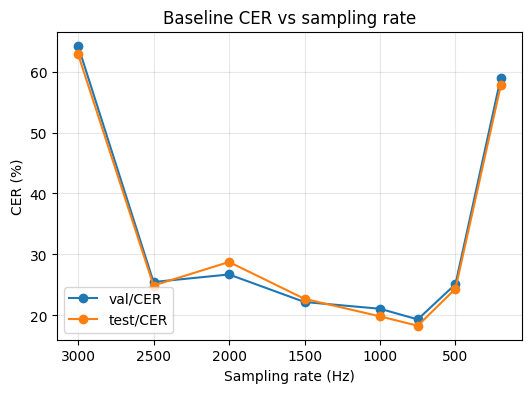

In [ ]:
import matplotlib.pyplot as plt

rates = [r["rate_hz"] for r in results]
val_cer = [r["val_cer"] for r in results]
test_cer = [r["test_cer"] for r in results]

plt.figure(figsize=(6,4))
plt.plot(rates, val_cer, marker="o", label="val/CER")
plt.plot(rates, test_cer, marker="o", label="test/CER")
plt.gca().invert_xaxis()  # optional: higher rate on left
plt.xlabel("Sampling rate (Hz)")
plt.ylabel("CER (%)")
plt.title("Baseline CER vs sampling rate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()